# Assignment 1
## Uncertainty and Sentiment in ARK Company Filings
FRE-GY 7871 A, Fall 2026. The analysis follows the current assignment brief. The instructor supplied data acquisition; the analysis additions and AI assistance are disclosed in `AI_USE.md`.

This is a retrospective event study, not an out-of-sample investment strategy. The complete specification and declared sensitivities are in [METHODOLOGY.md](METHODOLOGY.md).

## Reproduction
Run scripts `00` through `03`, then `05_get_price_actions.py` first. The downloads remain local and are excluded from Git. This notebook executes the analysis from those inputs, including text parsing, share recovery, exact-sample TF-IDF, all regressions and figures. A cached text matrix accelerates reruns; `build_text_data(force=True)` rebuilds it from the original HTML.

In [1]:
from pathlib import Path
import os, sys, runpy, json, subprocess
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
assert (ROOT/'src/config.py').exists(), 'Run the notebook from the repository root.'
os.environ['MPLCONFIGDIR']=str(ROOT/'outputs/mpl_cache')
sys.path.insert(0,str(ROOT))
RESULTS=ROOT/'outputs/analysis'
pd.set_option('display.max_rows',100)
pd.set_option('display.max_columns',30)
pd.set_option('display.float_format',lambda x:f'{x:.4f}')
def show_table(frame):
    labels={'measure':'Language measure','control_set':'Controls','beta':'Estimated coefficient',
            'se':'Standard error','t':'t statistic','p':'p-value (zero coefficient)','holm_p':'Adjusted p-value (Holm)',
            'n':'Observations','firms':'Number of companies','form':'Report type',
            'ci_low':'95% confidence interval: lower','ci_high':'95% confidence interval: upper',
            'within_beta':'Within-company slope','within_se':'Within-company standard error',
            'within_p':'Within-company p-value','within_holm_p':'Adjusted within-company p-value (Holm)',
            'aggregate_beta':'Overall slope','aggregate_ols_t':'Ordinary OLS t statistic',
            'aggregate_hac_t':'Newey-West t statistic','within_n':'Company-quarter observations',
            'term':'Variable','formula':'Regression equation','mde80':'Approximate detectable effect (80% power)'}
    readable={'negative_prop':'Negative-word proportion','negative_tfidf':'Negative-language TF-IDF',
              'uncertainty_prop':'Uncertainty-word proportion','uncertainty_tfidf':'Uncertainty TF-IDF',
              'none':'No controls','size':'Company size only','volatility':'Prior volatility only',
              'both':'Both controls','score_z':'Language score (+1 standard deviation)',
              'log_market_value':'Company size (log market value)','log_pre_vol':'Prior volatility (log)'}
    view=frame.copy()
    for col in ['measure','control_set','term']:
        if col in view:
            view[col]=view[col].replace(readable)
    display(view.rename(columns=labels))


## Numerical and timing tests
The tests cover the paper's weighting formula, same-corpus IDF, early closes, missing returns, compounding, split units, inline text, shell checkboxes, common-share classes, and redundant fixed effects.

In [2]:
r=subprocess.run([sys.executable,'-m','pytest','tests','-q'],cwd=ROOT,capture_output=True,text=True)
print(r.stdout)
assert r.returncode==0,r.stderr

..........                                                               [100%]
10 passed in 1.45s



## Run the complete analysis
The sample retains low-priced stocks without a minimum-price threshold. The primary outcome models compare no controls, company size only, prior volatility only, and both. Returns and volatility have separate sample waterfalls. Within each specification IDF is estimated on exactly its regression documents. Before/after pre-volatility-control pairs share the same sample.

In [3]:
analysis=runpy.run_path(str(ROOT/'scripts/06_run_analysis.py'),run_name='analysis_module')
summary=analysis['main']()

{
  "core_filings": 1624,
  "core_firms": 91,
  "core_forms": {
    "10-Q": 1228,
    "10-K": 396
  },
  "unique_downloaded_filings": 1682,
  "duplicate_security_records_removed": 20,
  "shell_filings_removed": 58,
  "unknown_shell_status": 0,
  "vol_sample": 1591,
  "return_sample": 1592,
  "shifted_event_days": 921,
  "shares_sources": {
    "cover_xbrl_total": 1080,
    "cover_xbrl_class_sum": 571,
    "cover_sentence": 26,
    "same_accession_instant_fact": 4,
    "unresolved": 1
  },
  "core_unresolved_shares": 15,
  "cover_sentence_recoveries": 26,
  "parser_old_words": 48537683,
  "parser_new_words": 62590430,
  "lexicon_overlap": 40,
  "top30_negative_share": 46.393553691827,
  "top30_uncertainty_share": 90.43154482654644,
  "quarterly_observations": 20,
  "correlations": [
    {
      "form": "10-K",
      "weight": "prop",
      "correlation": 0.7217520986983796
    },
    {
      "form": "10-K",
      "weight": "tfidf",
      "correlation": 0.8379485958917098
    },
    {
  

## Table 1 — Sample filters
The universe table counts securities/issuers. The filing table counts unique documents; the raw 1,702 ticker-filing rows contain 20 duplicate Alphabet reports. Unknown SEC mappings are reported as unresolved, not presumed to be private firms. Shell status is assessed at the filing date.

In [4]:
show_table(pd.read_csv(RESULTS/'table1_universe.csv'))
show_table(pd.read_csv(RESULTS/'table1_filings.csv'))

,filter,remaining,removed
0,Unique cleaned securities in frozen snapshot,124,0
1,SEC ticker-to-CIK mapping found,117,7
2,At least one 2021-2025 10-K/10-Q,93,24
3,Unique companies (GOOG and GOOGL count as one),92,1


,branch,filter,removed,remaining,Number of companies
0,text,Starting unique filings,0,1682,92
1,text,Valid acceptance timestamp,0,1682,92
2,text,"At least 2,000 narrative words",0,1682,92
3,text,Exclude explicitly identified shell companies,58,1624,91
4,volatility,Starting unique filings,0,1624,91
5,volatility,Complete 63-day pre-filing returns and positiv...,32,1592,90
6,volatility,Available dated share count and positive compa...,0,1592,90
7,volatility,Complete 63-day post-filing returns,1,1591,90
8,return,Starting unique filings,0,1624,91
9,return,Complete 63-day pre-filing returns and positiv...,32,1592,90


## Measures
Negative language and uncertainty remain separate. A proportional score is category occurrences divided by all tokens. Equation (1) is

$$w_{ij}=\frac{1+\ln(tf_{ij})}{1+\ln(a_j)}\ln(N/df_i),\quad tf_{ij}>0,$$

and zero otherwise, with $a_j=L_j/U_j$, the mean token frequency across all distinct document terms. The category score sums its term weights. Natural logarithms and no smoothing are used. The assignment's nonzero Negative flags include ten removed terms; active-only Negative is a sensitivity.

## Table 2 — Descriptive statistics
Proportional measures in this table are expressed as percentages of all words. TF-IDF scores are sums of weights. Annual and quarterly filings are shown separately.

In [5]:
show_table(pd.read_csv(RESULTS/'table2.csv'))
show_table(pd.read_csv(RESULTS/'tone_correlations.csv'))
print('Dictionary overlap:',summary['lexicon_overlap'],'words')

,Report type,Language measure,Observations,mean,sd,p25,median,p75
0,10-K,Negative-word proportion,396,2.3472,0.4062,2.0844,2.3608,2.6202
1,10-K,Negative-language TF-IDF,396,163.6839,54.4804,122.1918,155.0447,204.9151
2,10-K,Uncertainty-word proportion,396,1.9472,0.2398,1.8026,1.9690,2.1185
3,10-K,Uncertainty TF-IDF,396,26.6429,8.1196,21.0620,25.5421,31.2009
4,10-Q,Negative-word proportion,1228,2.1332,0.9479,1.2848,1.9520,3.0204
5,10-Q,Negative-language TF-IDF,1228,80.2967,66.2437,24.0206,56.2435,131.1088
6,10-Q,Uncertainty-word proportion,1228,1.8285,0.5870,1.3271,1.6686,2.4192
7,10-Q,Uncertainty TF-IDF,1228,13.5046,7.2711,7.7880,11.9092,18.7195


,Report type,weight,correlation
0,10-K,prop,0.7218
1,10-K,tfidf,0.8379
2,10-Q,prop,0.8506
3,10-Q,tfidf,0.9206


Dictionary overlap: 40 words


## Table 3 — Thirty most common words per list
Each share uses all occurrences on its own category list as the denominator. The lists' overlap and correlated topics mean their scores are not statistically independent.

In [6]:
t3=pd.read_csv(RESULTS/'table3.csv')
for category in ['Negative','Uncertainty']:
    display(Markdown('### '+category))
    show_table(t3.loc[t3.category.eq(category)].reset_index(drop=True))

### Negative

,category,rank,word,count,share_pct
0,Negative,1,LOSS,77905,5.1245
1,Negative,2,ADVERSELY,62801,4.1310
2,Negative,3,LOSSES,47263,3.1089
3,Negative,4,CLAIMS,45110,2.9673
4,Negative,5,ADVERSE,42122,2.7707
5,Negative,6,AGAINST,36255,2.3848
6,Negative,7,UNABLE,29862,1.9643
7,Negative,8,LITIGATION,29647,1.9501
8,Negative,9,HARM,28385,1.8671
9,Negative,10,FAILURE,27561,1.8129


### Uncertainty

,category,rank,word,count,share_pct
0,Uncertainty,1,MAY,439120,35.2152
1,Uncertainty,2,COULD,231154,18.5374
2,Uncertainty,3,RISK,62055,4.9765
3,Uncertainty,4,RISKS,55812,4.4758
4,Uncertainty,5,BELIEVE,36518,2.9286
5,Uncertainty,6,APPROXIMATELY,31896,2.5579
6,Uncertainty,7,ASSUMPTIONS,23943,1.9201
7,Uncertainty,8,INTANGIBLE,20499,1.6439
8,Uncertainty,9,POSSIBLE,15673,1.2569
9,Uncertainty,10,UNCERTAINTIES,14415,1.1560


## Figure 1 — Quarterly language scores and VIX
Average within issuer/form/filing quarter before averaging across issuers. Separate 10-K and 10-Q to expose form composition. VIX is quarterly mean market uncertainty on the right axis, not a substitute for company-level realized volatility.

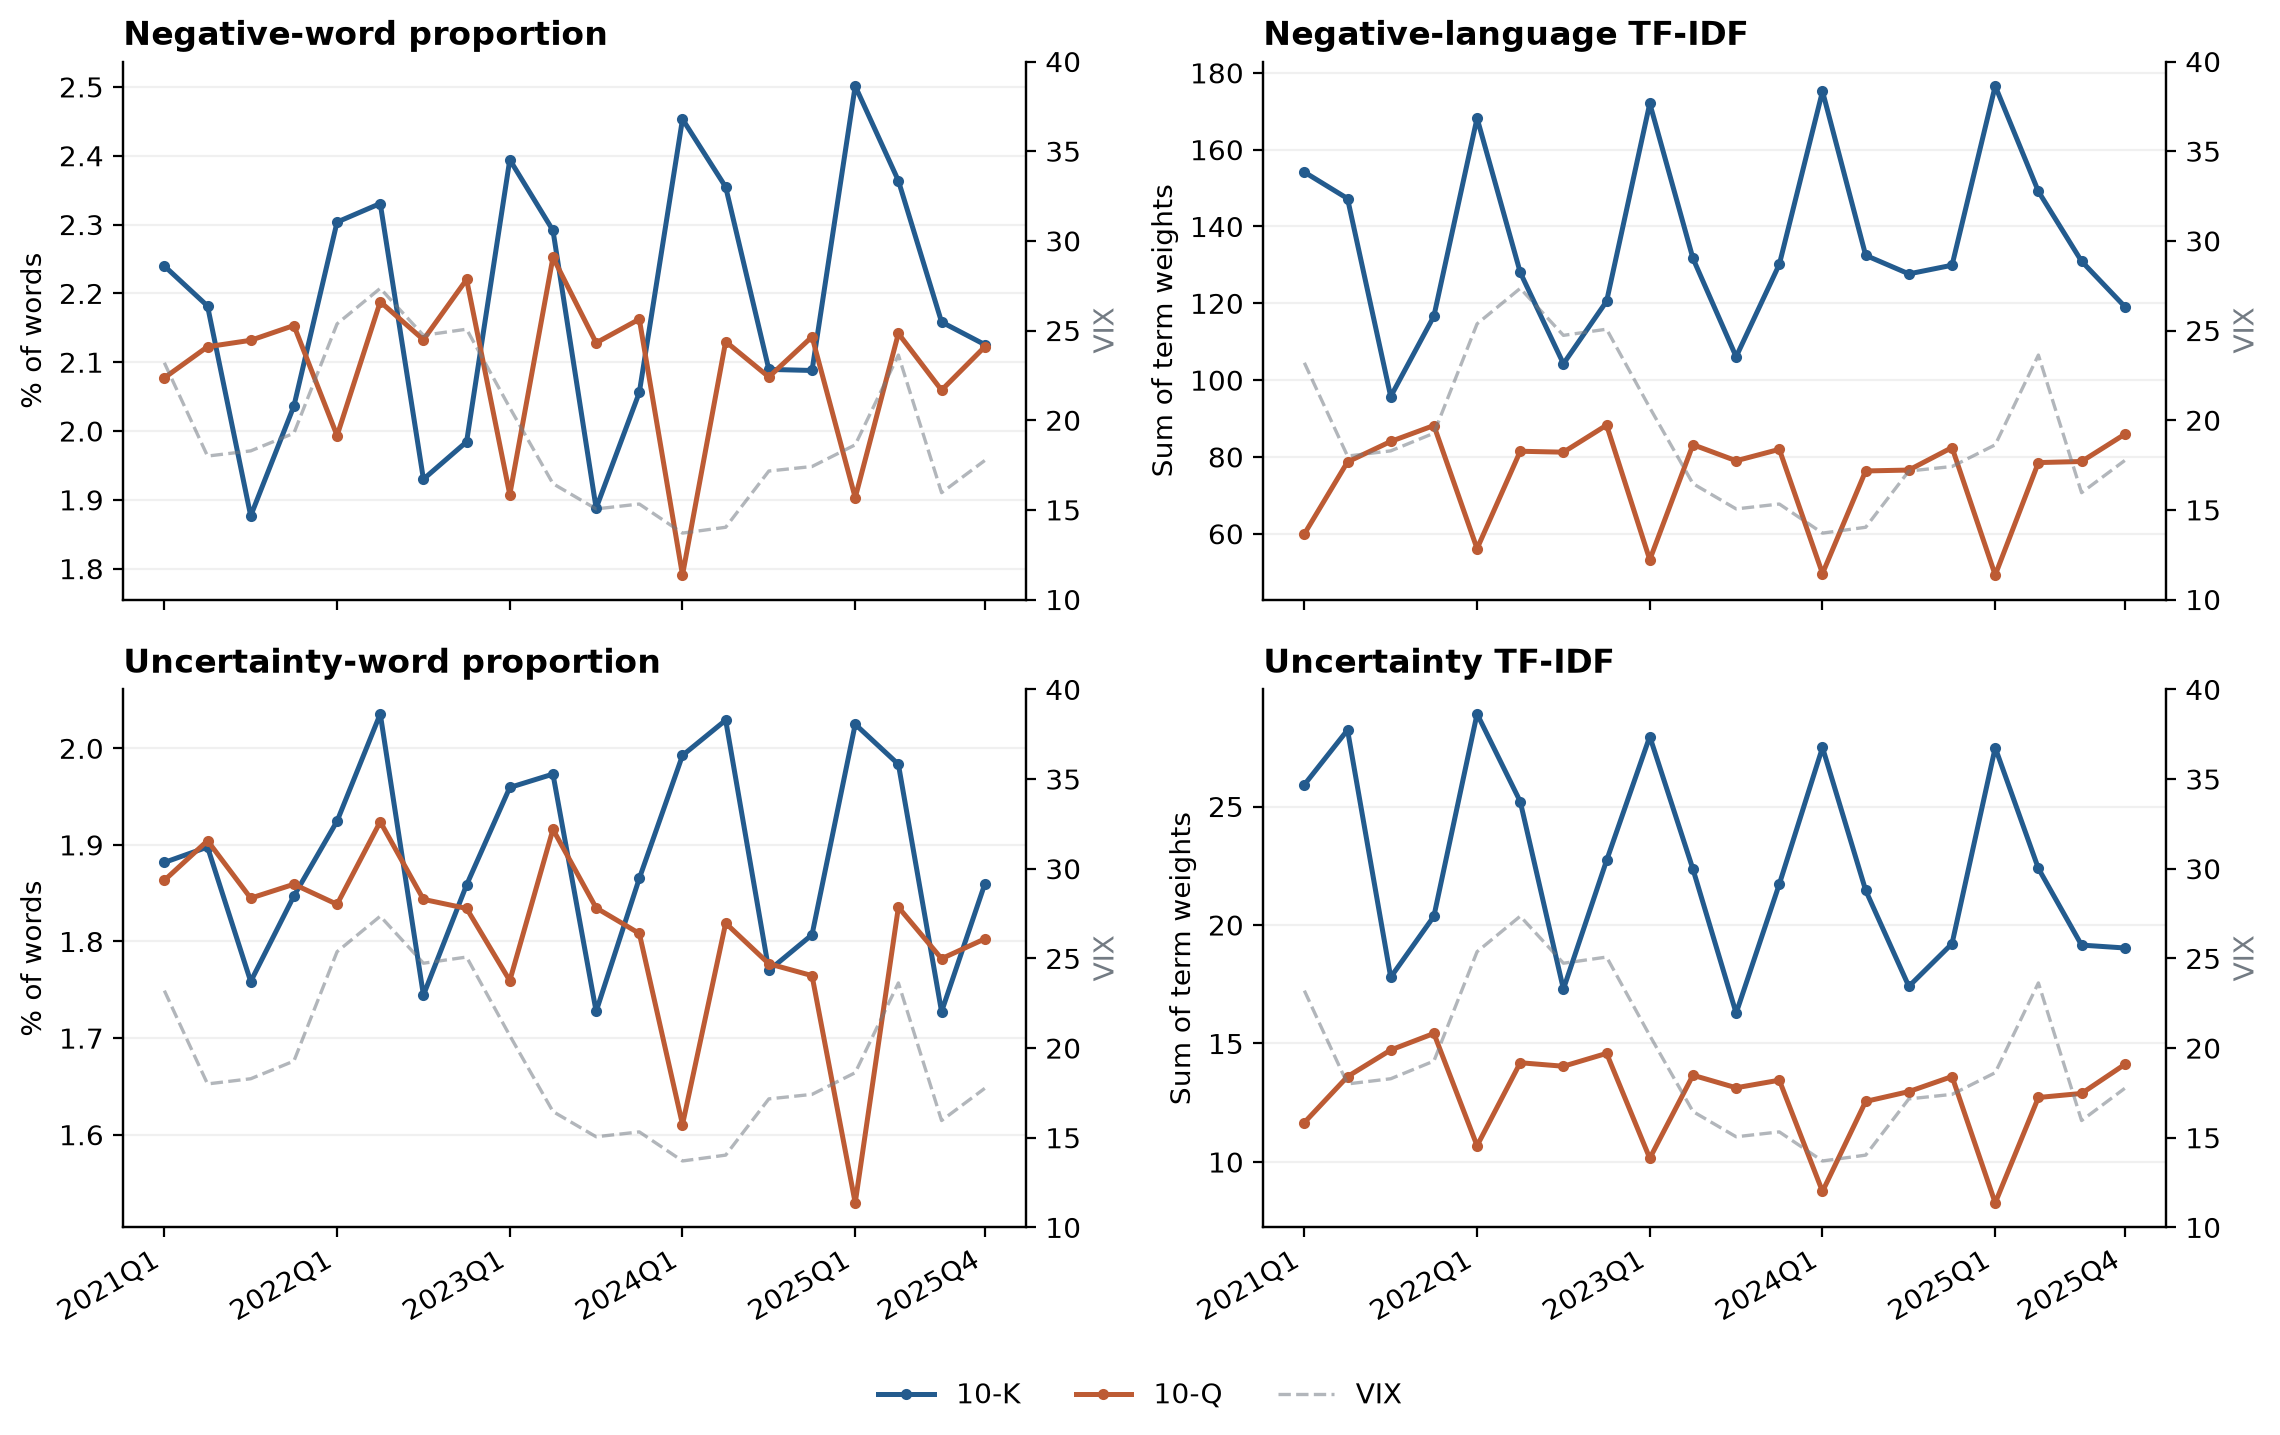

,Report type,quarter,negative_prop,negative_tfidf,uncertainty_prop,uncertainty_tfidf
0,10-K,2021Q1,0.0224,154.1622,0.0188,25.9201
1,10-K,2021Q2,0.0218,147.2740,0.0190,28.2276
2,10-K,2021Q3,0.0188,95.7287,0.0176,17.7963
3,10-K,2021Q4,0.0204,116.6612,0.0185,20.3679
4,10-K,2022Q1,0.0230,168.2110,0.0192,28.9086
5,10-K,2022Q2,0.0233,128.0380,0.0204,25.2091
6,10-K,2022Q3,0.0193,104.2649,0.0174,17.2953
7,10-K,2022Q4,0.0198,120.5289,0.0186,22.7240
8,10-K,2023Q1,0.0239,172.0514,0.0196,27.9515
9,10-K,2023Q2,0.0229,131.6858,0.0197,22.3545


In [7]:
display(Image(filename=str(RESULTS/'figure1.png')))
show_table(pd.read_csv(RESULTS/'quarterly_tone.csv'))

## Table 4 — Trend tests
The primary trend test includes issuer and quarter-of-year effects with issuer-clustered SEs. Aggregate OLS and Newey-West (four lags, finite-sample correction) t statistics are both reported. Each slope is in SDs per quarter. Holm correction covers the four category-by-form within-issuer tests separately for each weighting scheme.

In [8]:
t4=pd.read_csv(RESULTS/'table4.csv')
show_table(t4[['form','measure','aggregate_beta','aggregate_ols_t','aggregate_hac_t','within_beta','within_se','within_p','within_holm_p','within_n','firms']])

,Report type,Language measure,Overall slope,Ordinary OLS t statistic,Newey-West t statistic,Within-company slope,Within-company standard error,Within-company p-value,Adjusted within-company p-value (Holm),Company-quarter observations,Number of companies
0,10-K,Negative-word proportion,0.0318,6.5325,9.4962,0.0345,0.0047,0.0000,0.0000,392,83
1,10-K,Negative-language TF-IDF,0.0176,2.8519,4.7340,0.0133,0.0042,0.0022,0.0067,392,83
2,10-K,Uncertainty-word proportion,0.0119,1.8260,1.7286,0.0249,0.0049,0.0000,0.0000,392,83
3,10-K,Uncertainty TF-IDF,-0.0124,-1.4374,-2.2295,-0.0077,0.0043,0.0769,0.1539,392,83
4,10-Q,Negative-word proportion,-0.0060,-2.5706,-3.3518,-0.0042,0.0043,0.3325,0.3325,1224,90
5,10-Q,Negative-language TF-IDF,-0.0062,-4.1642,-4.0618,-0.0072,0.0045,0.1129,0.1539,1224,90
6,10-Q,Uncertainty-word proportion,-0.0161,-4.3015,-4.5183,-0.0109,0.0046,0.0192,0.0384,1224,90
7,10-Q,Uncertainty TF-IDF,-0.0179,-6.2779,-6.1633,-0.0181,0.0048,0.0003,0.0014,1224,90


## Table 5 — Uncertainty and next-quarter volatility
The outcome is log annualized volatility on trading days [4,66]. Pre-volatility uses [-63,-1]. Four models contain the language score plus an intercept, then add size only, prior volatility only, or both. No other controls or fixed effects enter these primary models. Size is log market value, included because company scale may relate to both language scores and market behavior. It is a methodological choice, not explicitly required by the assignment. The score is standardized within the same complete-case corpus, so the coefficient change is not a change in sample composition.

In [9]:
t5=pd.read_csv(RESULTS/'table5.csv')
show_table(t5[['measure','control_set','formula','beta','se','t','p','holm_p','ci_low','ci_high','n','firms','corpus']])
assert t5.groupby('measure').corpus.nunique().eq(1).all()
c=pd.read_csv(RESULTS/'all_regression_coefficients.csv')
show_table(c.loc[c.model.isin(t5.model)])

,Language measure,Controls,Regression equation,Estimated coefficient,Standard error,t statistic,p-value (zero coefficient),Adjusted p-value (Holm),95% confidence interval: lower,95% confidence interval: upper,Observations,Number of companies,corpus
0,Uncertainty-word proportion,No controls,log_post_vol ~ score_z,0.1204,0.0368,3.2708,0.0015,NaN,0.0473,0.1936,1591,90,9255c7cfd732c13e
1,Uncertainty-word proportion,Company size only,log_post_vol ~ score_z + log_market_value,0.1170,0.0261,4.4894,0.0000,NaN,0.0652,0.1688,1591,90,9255c7cfd732c13e
2,Uncertainty-word proportion,Prior volatility only,log_post_vol ~ score_z + log_pre_vol,0.0257,0.0102,2.5181,0.0136,NaN,0.0054,0.0460,1591,90,9255c7cfd732c13e
3,Uncertainty-word proportion,Both controls,log_post_vol ~ score_z + log_market_value + lo...,0.0381,0.0089,4.2670,0.0000,0.0001,0.0203,0.0558,1591,90,9255c7cfd732c13e
4,Uncertainty TF-IDF,No controls,log_post_vol ~ score_z,0.1382,0.0267,5.1811,0.0000,NaN,0.0852,0.1912,1591,90,9255c7cfd732c13e
5,Uncertainty TF-IDF,Company size only,log_post_vol ~ score_z + log_market_value,0.1064,0.0234,4.5420,0.0000,NaN,0.0599,0.1529,1591,90,9255c7cfd732c13e
6,Uncertainty TF-IDF,Prior volatility only,log_post_vol ~ score_z + log_pre_vol,0.0418,0.0096,4.3459,0.0000,NaN,0.0227,0.0609,1591,90,9255c7cfd732c13e
7,Uncertainty TF-IDF,Both controls,log_post_vol ~ score_z + log_market_value + lo...,0.0435,0.0092,4.7262,0.0000,0.0000,0.0252,0.0618,1591,90,9255c7cfd732c13e


,model,Variable,Estimated coefficient,Standard error,t statistic,p-value (zero coefficient),95% confidence interval: lower,95% confidence interval: upper
760,volatility_pooled_uncertainty_prop_none,Intercept,-0.6841,0.0441,-15.5112,0.0000,-0.7717,-0.5964
761,volatility_pooled_uncertainty_prop_none,Language score (+1 standard deviation),0.1204,0.0368,3.2708,0.0015,0.0473,0.1936
762,volatility_pooled_uncertainty_prop_size,Intercept,2.2039,0.2986,7.3811,0.0000,1.6106,2.7972
763,volatility_pooled_uncertainty_prop_size,Language score (+1 standard deviation),0.1170,0.0261,4.4894,0.0000,0.0652,0.1688
764,volatility_pooled_uncertainty_prop_size,Company size (log market value),-0.1237,0.0131,-9.4345,0.0000,-0.1498,-0.0977
765,volatility_pooled_uncertainty_prop_volatility,Intercept,-0.1808,0.0197,-9.2015,0.0000,-0.2199,-0.1418
766,volatility_pooled_uncertainty_prop_volatility,Language score (+1 standard deviation),0.0257,0.0102,2.5181,0.0136,0.0054,0.0460
767,volatility_pooled_uncertainty_prop_volatility,Prior volatility (log),0.7487,0.0269,27.7978,0.0000,0.6952,0.8023
768,volatility_pooled_uncertainty_prop_both,Intercept,0.7475,0.1453,5.1451,0.0000,0.4588,1.0362
769,volatility_pooled_uncertainty_prop_both,Language score (+1 standard deviation),0.0381,0.0089,4.2670,0.0000,0.0203,0.0558


## Table 6 — Sentiment and filing-period excess returns
The outcome is stock minus SPY buy-and-hold return over [0,3], in percentage points. The same four control specifications are compared on one common sample, so even the no-control model uses filings with an available pre-volatility baseline. The minimum detectable effect is an approximate 80%-power precision diagnostic, not observed power.

In [10]:
t6=pd.read_csv(RESULTS/'table6.csv')
show_table(t6[['measure','control_set','formula','beta','se','t','p','holm_p','ci_low','ci_high','mde80','n','firms']])
show_table(c.loc[c.model.isin(t6.model)])
assert t6.groupby('measure').corpus.nunique().eq(1).all()

,Language measure,Controls,Regression equation,Estimated coefficient,Standard error,t statistic,p-value (zero coefficient),Adjusted p-value (Holm),95% confidence interval: lower,95% confidence interval: upper,Approximate detectable effect (80% power),Observations,Number of companies
0,Negative-word proportion,No controls,excess_return ~ score_z,-0.3546,0.2808,-1.2630,0.2099,NaN,-0.9125,0.2033,0.7942,1592,90
1,Negative-word proportion,Company size only,excess_return ~ score_z + log_market_value,-0.3657,0.2756,-1.3271,0.1879,NaN,-0.9132,0.1818,0.7795,1592,90
2,Negative-word proportion,Prior volatility only,excess_return ~ score_z + log_pre_vol,-0.2614,0.2848,-0.9178,0.3612,NaN,-0.8274,0.3045,0.8057,1592,90
3,Negative-word proportion,Both controls,excess_return ~ score_z + log_market_value + l...,-0.2093,0.2845,-0.7357,0.4639,0.4838,-0.7747,0.3560,0.8048,1592,90
4,Negative-language TF-IDF,No controls,excess_return ~ score_z,-0.5068,0.2973,-1.7046,0.0918,NaN,-1.0976,0.0840,0.8410,1592,90
5,Negative-language TF-IDF,Company size only,excess_return ~ score_z + log_market_value,-0.5043,0.3063,-1.6465,0.1032,NaN,-1.1130,0.1043,0.8664,1592,90
6,Negative-language TF-IDF,Prior volatility only,excess_return ~ score_z + log_pre_vol,-0.3905,0.3233,-1.2080,0.2303,NaN,-1.0329,0.2519,0.9145,1592,90
7,Negative-language TF-IDF,Both controls,excess_return ~ score_z + log_market_value + l...,-0.3781,0.3209,-1.1781,0.2419,0.4838,-1.0158,0.2596,0.9078,1592,90


,model,Variable,Estimated coefficient,Standard error,t statistic,p-value (zero coefficient),95% confidence interval: lower,95% confidence interval: upper
1034,return_pooled_negative_prop_none,Intercept,-0.2388,0.2713,-0.8799,0.3813,-0.7779,0.3004
1035,return_pooled_negative_prop_none,Language score (+1 standard deviation),-0.3546,0.2808,-1.2630,0.2099,-0.9125,0.2033
1036,return_pooled_negative_prop_size,Intercept,-1.4003,2.8648,-0.4888,0.6262,-7.0925,4.2919
1037,return_pooled_negative_prop_size,Language score (+1 standard deviation),-0.3657,0.2756,-1.3271,0.1879,-0.9132,0.1818
1038,return_pooled_negative_prop_size,Company size (log market value),0.0498,0.1172,0.4246,0.6721,-0.1831,0.2826
1039,return_pooled_negative_prop_volatility,Intercept,-0.8580,0.5290,-1.6220,0.1083,-1.9091,0.1931
1040,return_pooled_negative_prop_volatility,Language score (+1 standard deviation),-0.2614,0.2848,-0.9178,0.3612,-0.8274,0.3045
1041,return_pooled_negative_prop_volatility,Prior volatility (log),-0.9208,0.5999,-1.5348,0.1284,-2.1128,0.2713
1042,return_pooled_negative_prop_both,Intercept,1.4928,3.7571,0.3973,0.6921,-5.9725,8.9582
1043,return_pooled_negative_prop_both,Language score (+1 standard deviation),-0.2093,0.2845,-0.7357,0.4639,-0.7747,0.3560


## Outcome sensitivities
All sensitivities use both size and prior volatility. Form-specific samples re-estimate IDF. Other checks add issuer, calendar-quarter and form effects, use two-way clustering, change the return benchmark to ARKK, or remove retired Negative terms. Negative nuisance variances in the two-way covariance are disclosed; they are not clipped. There are only 20 time clusters, so those sensitivities also need caution.

In [11]:
models=pd.read_csv(RESULTS/'all_outcome_models.csv')
show_table(models[['outcome','variant','measure','control_set','formula','beta','se','p','n','corpus','negative_variance_terms']])

,outcome,variant,Language measure,Controls,Regression equation,Estimated coefficient,Standard error,p-value (zero coefficient),Observations,corpus,negative_variance_terms
0,volatility,pooled,Uncertainty-word proportion,No controls,log_post_vol ~ score_z,0.1204,0.0368,0.0015,1591,9255c7cfd732c13e,NaN
1,volatility,pooled,Uncertainty-word proportion,Company size only,log_post_vol ~ score_z + log_market_value,0.1170,0.0261,0.0000,1591,9255c7cfd732c13e,NaN
2,volatility,pooled,Uncertainty-word proportion,Prior volatility only,log_post_vol ~ score_z + log_pre_vol,0.0257,0.0102,0.0136,1591,9255c7cfd732c13e,NaN
3,volatility,pooled,Uncertainty-word proportion,Both controls,log_post_vol ~ score_z + log_market_value + lo...,0.0381,0.0089,0.0000,1591,9255c7cfd732c13e,NaN
4,volatility,pooled,Uncertainty TF-IDF,No controls,log_post_vol ~ score_z,0.1382,0.0267,0.0000,1591,9255c7cfd732c13e,NaN
5,volatility,pooled,Uncertainty TF-IDF,Company size only,log_post_vol ~ score_z + log_market_value,0.1064,0.0234,0.0000,1591,9255c7cfd732c13e,NaN
6,volatility,pooled,Uncertainty TF-IDF,Prior volatility only,log_post_vol ~ score_z + log_pre_vol,0.0418,0.0096,0.0000,1591,9255c7cfd732c13e,NaN
7,volatility,pooled,Uncertainty TF-IDF,Both controls,log_post_vol ~ score_z + log_market_value + lo...,0.0435,0.0092,0.0000,1591,9255c7cfd732c13e,NaN
8,volatility,firm_FE,Uncertainty-word proportion,Both controls,log_post_vol ~ score_z + log_market_value + lo...,-0.0088,0.0102,0.3928,1591,9255c7cfd732c13e,NaN
9,volatility,firm_FE,Uncertainty TF-IDF,Both controls,log_post_vol ~ score_z + log_market_value + lo...,-0.0047,0.0118,0.6918,1591,9255c7cfd732c13e,NaN


## Interpretation and limitations
Annual-report negative language rises within issuers under both weighting schemes; uncertainty trends differ by form and weight. The pre-volatility control attenuates the uncertainty coefficient, so much of the association reflects existing volatility. With both controls, pooled associations remain significant after family adjustment. Adding issuer, calendar-quarter and form effects makes both uncertainty coefficients negative and insignificant, so a robust within-issuer predictive relationship is not established. The four-day return test is imprecise. These are different tests with different evidence; a blanket claim that the sample is too small is not warranted.

Adding company size to the prior-volatility model raises the uncertainty coefficient. Conditional on prior volatility, uncertainty and size are positively associated, whereas size has a negative coefficient in the full model. Omitting size lowers the uncertainty coefficient; adding it changes the conditional comparison and does not establish causation.

The 2026 holdings snapshot creates survivorship/selection bias. It does not reveal former holdings that disappeared. Correct acceptance times and contemporaneous share counts do not cure that selection. Further limits include full-corpus scoring, 20 aggregate quarters, daily timing, overlapping windows, and multi-class valuation approximations. The next improvement is a historical holdings universe followed by a held-out forecasting evaluation.

See the short PDF report for the test-by-test discussion and `AI_USE.md` for the authorship disclosure.

## Plain-language table guide
A score is the measured amount of uncertainty or negative language. One standard deviation is a common scale for comparing coefficients. A score p-value tests a zero score coefficient; an adjusted p-value accounts for multiple testing. Not applied means no adjustment was made, not a nonsignificant finding. Parentheses in the PDF contain company-clustered standard errors. Log means natural logarithm. P25/P75 are percentiles. Internal variable `score_z` means the standardized language score named by that model. The intercept is its fitted baseline.

# Additional analysis choices

The current report follows the ARK / 2021-2025 assignment. The brief explicitly
requires the six tables, quarterly figure with VIX, separate report types,
aggregate and within-company trends, Newey-West errors for aggregate trends, and
volatility regressions with and without a prior-volatility control.

The principal additional choices appearing in the report are:

| Location | Additional specification or analysis |
|---|---|
| Table 1 | Exclude explicitly identified shell-company reports and require at least 2,000 words. Count duplicate company reports once, using GOOGL for Alphabet. No minimum share-price threshold applies. |
| Table 2 and accompanying discussion | Report dictionary overlap and correlations between the two language measures. |
| Tables 5 and 6 | Include company size and compare four models: no controls, size only, prior volatility only, and both. Use the same sample in each comparison. |
| Tables 4-6 | Apply Holm adjustments to the specified groups of tests. Use company-clustered inference for repeated filings; the exact clustering and correction settings are methodological choices. |
| Table 5 and notebook | Check separate report types, added company/time/report-type effects, two-way clustering, an ARKK benchmark, and an active-only Negative word list. |
| Table 6 discussion | Calculate an approximate 80%-power minimum detectable return effect. The assignment calls for discussing precision but does not prescribe this calculation. |
| Supplementary figure | Plot median four-day excess returns across negative-word-proportion quintiles. This is separate from the required quarterly Figure 1. |

Other necessary implementation choices include the exact 63-trading-day
volatility windows, the [0,3] return window, the SEC acceptance-time event rule,
SPY excess returns, natural-log transformations, share-count valuation and split
alignment, four Newey-West lags, text parsing, sample-specific IDF and score
standardization. Some follow the paper or starter code; their exact settings
are not individually specified in the brief. See METHODOLOGY.md for definitions.

The primary outcome models do not include prior cumulative return, turnover,
industry effects or other hidden controls. Company/time/report-type effects
appear only in a separately labeled supplementary outcome specification.
Seasonal and company effects remain in the required trend analysis.

The report's appendix summarizes these choices. AI assistance and the development
history are documented separately in AI_USE.md.
